In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Found 5 NPZ files:
 - img_1_100_samples_aug.npz
 - img_2_100_samples_aug.npz
 - img_3_100_samples_aug.npz
 - img_4_100_samples_aug.npz
 - img_5_100_samples_aug.npz

Checking file: img_1_100_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Checking file: img_2_100_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Checking file: img_3_100_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Checking file: img_4_100_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Checking file: img_5_100_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Final merged shapes:
Embeddings: (2500, 1024)
Labels: (2500,)
Image IDs: (2500,)

PCA explained variance:
PC1: 12.42%
PC2: 8.95%
PC3: 8.19%
Total PC1 + PC2 + PC3: 29.55%

Class counts:
class_name
Hepatocytes    500
Stellate       500
Other          500
Endothelial    500
Kupffer        500
Name: count, dtype: int64

Marker assignment:
img_1_100_samples_aug: x
img_2_100_samples_aug: *
img_3_100_samples_aug: o
img_4_100_sam

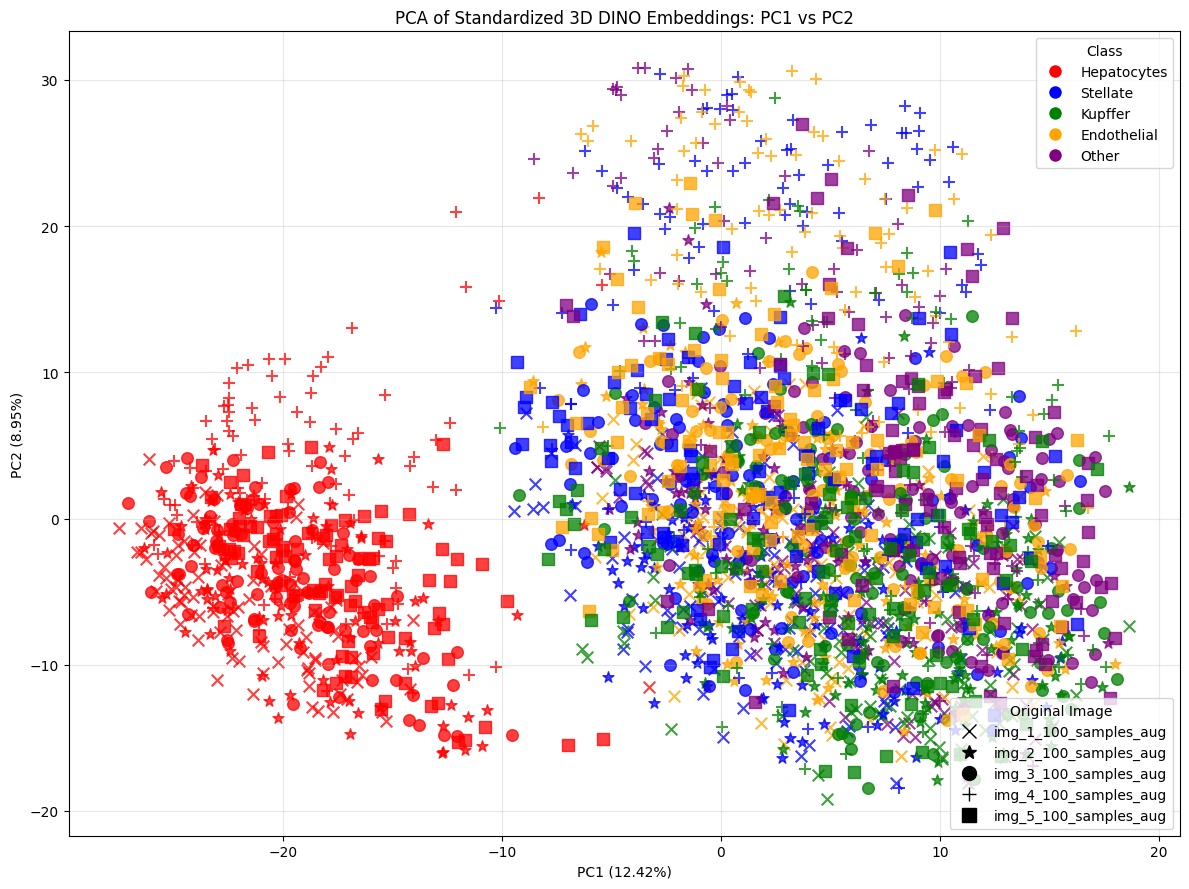

Saved: /content/drive/MyDrive/Paper/PCA/dino100/PCA_DINO3D_embeddings_scaled_PC1_vs_PC2.svg


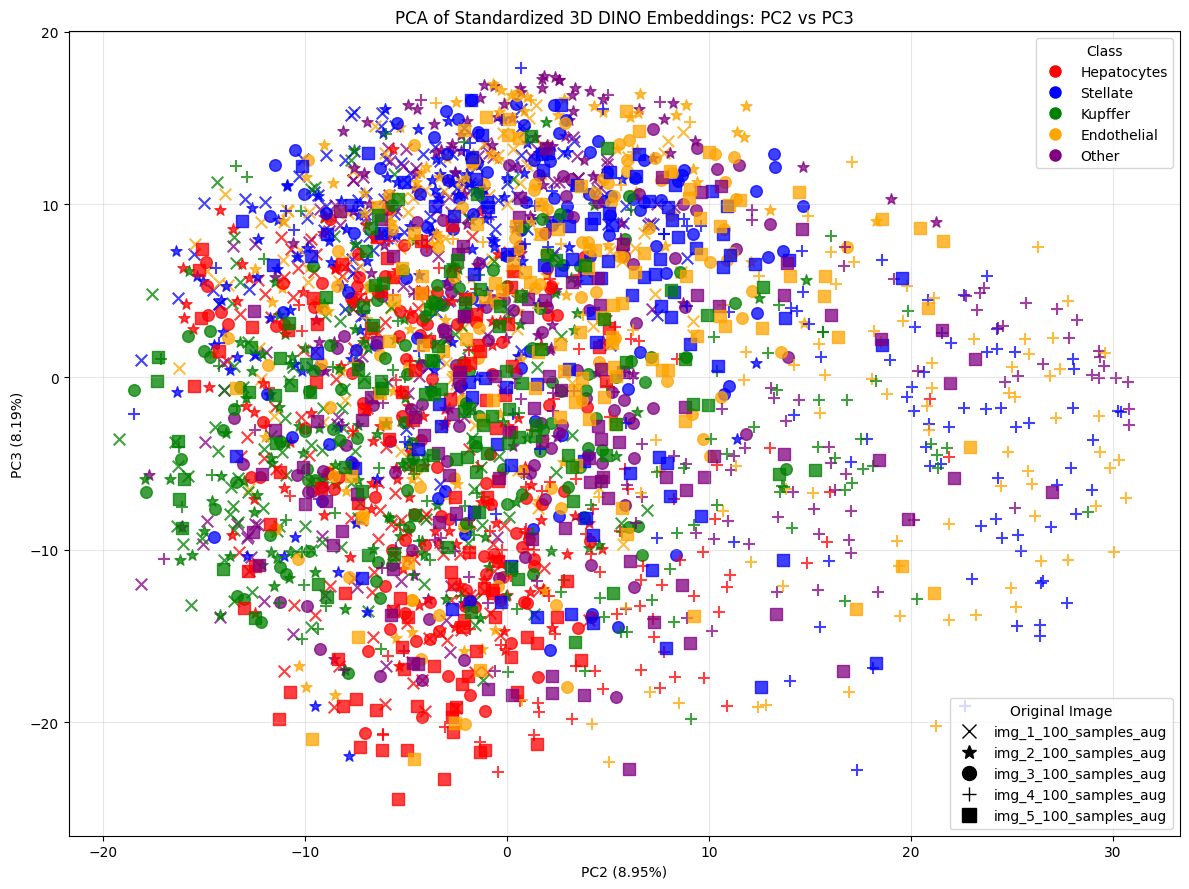

Saved: /content/drive/MyDrive/Paper/PCA/dino100/PCA_DINO3D_embeddings_scaled_PC2_vs_PC3.svg


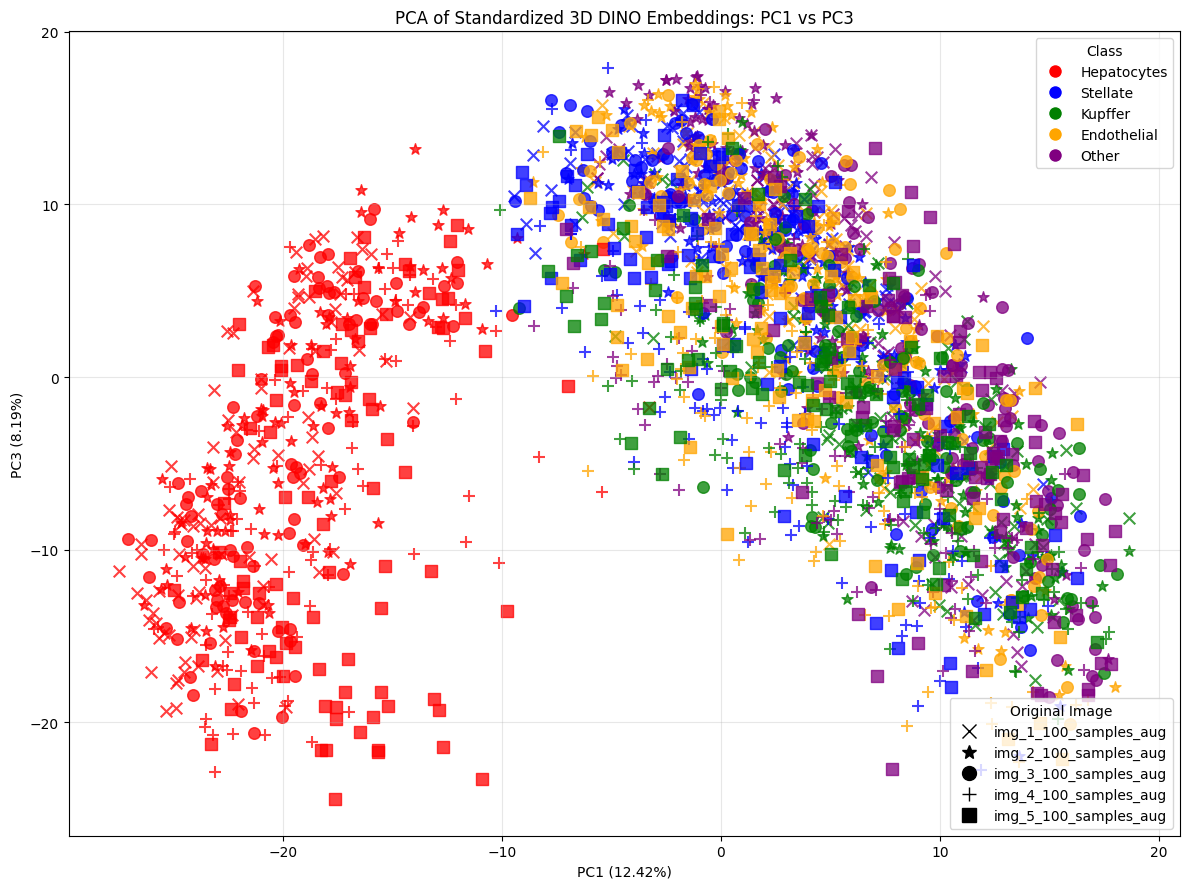

Saved: /content/drive/MyDrive/Paper/PCA/dino100/PCA_DINO3D_embeddings_scaled_PC1_vs_PC3.svg

Saved PCA coordinates in: /content/drive/MyDrive/Paper/PCA/dino100/PCA_DINO3D_embeddings_scaled_coordinates.csv


In [ ]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D


# ============================================================
# 1. Input folder
# ============================================================

embeddings_folder = "/content/drive/MyDrive/Paper/processed_data 1/processed_data/DINO3D_embeddings/embedding_aug_100"


# ============================================================
# 2. Output folder
# ============================================================

output_dir = Path("/content/drive/MyDrive/Paper/PCA/dino100")
output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. Find NPZ files
# ============================================================

npz_files = sorted(glob.glob(os.path.join(embeddings_folder, "*.npz")))

print(f"Found {len(npz_files)} NPZ files:")
for f in npz_files:
    print(" -", os.path.basename(f))

if len(npz_files) == 0:
    raise FileNotFoundError(f"No NPZ files found in: {embeddings_folder}")


# ============================================================
# 4. Class names
# ============================================================

class_map = {
    1: "Hepatocytes",
    2: "Stellate",
    3: "Kupffer",
    4: "Endothelial",
    5: "Other"
}


# ============================================================
# 5. Markers and colors
# ============================================================

available_markers = ["x", "*", "o", "+", "s", "D", "^", "v", "<", ">"]

color_map = {
    "Hepatocytes": "red",
    "Stellate": "blue",
    "Kupffer": "green",
    "Endothelial": "orange",
    "Other": "purple"
}


# ============================================================
# 6. Load and merge embeddings
# ============================================================

all_embeddings = []
all_labels = []
all_image_ids = []

for file_path in npz_files:
    data = np.load(file_path, allow_pickle=True)

    print(f"\nChecking file: {os.path.basename(file_path)}")
    print("Keys:", data.files)

    X = data["embeddings"]
    y = data["labels"]

    image_id = os.path.splitext(os.path.basename(file_path))[0]

    all_embeddings.append(X)
    all_labels.append(y)
    all_image_ids.extend([image_id] * len(y))

X_all = np.vstack(all_embeddings)
y_all = np.concatenate(all_labels)
image_ids_all = np.array(all_image_ids)

print("\nFinal merged shapes:")
print("Embeddings:", X_all.shape)
print("Labels:", y_all.shape)
print("Image IDs:", image_ids_all.shape)


# ============================================================
# 7. StandardScaler + PCA
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pc_percentages = {
    "PC1": pca.explained_variance_ratio_[0] * 100,
    "PC2": pca.explained_variance_ratio_[1] * 100,
    "PC3": pca.explained_variance_ratio_[2] * 100
}

print("\nPCA explained variance:")
for pc, value in pc_percentages.items():
    print(f"{pc}: {value:.2f}%")

print(f"Total PC1 + PC2 + PC3: {sum(pc_percentages.values()):.2f}%")


# ============================================================
# 8. Build DataFrame
# ============================================================

df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "label": y_all,
    "image_id": image_ids_all
})

df["class_name"] = df["label"].map(class_map)

print("\nClass counts:")
print(df["class_name"].value_counts(dropna=False))


# ============================================================
# 9. Marker assignment per NPZ file
# ============================================================

unique_images = sorted(df["image_id"].unique())

if len(unique_images) > len(available_markers):
    raise ValueError(
        f"You have {len(unique_images)} images but only {len(available_markers)} markers defined. "
        f"Add more markers to available_markers."
    )

marker_map = {img: available_markers[i] for i, img in enumerate(unique_images)}

print("\nMarker assignment:")
for img, mk in marker_map.items():
    print(f"{img}: {mk}")


# ============================================================
# 10. Function to plot PCA pairs
# ============================================================

def plot_pca_pair(df, x_pc, y_pc, filename):
    plt.figure(figsize=(12, 9))

    for img in unique_images:
        for cls in df["class_name"].dropna().unique():
            subset = df[(df["image_id"] == img) & (df["class_name"] == cls)]

            if subset.empty:
                continue

            plt.scatter(
                subset[x_pc],
                subset[y_pc],
                c=color_map[cls],
                marker=marker_map[img],
                s=70,
                alpha=0.75
            )

    plt.xlabel(f"{x_pc} ({pc_percentages[x_pc]:.2f}%)")
    plt.ylabel(f"{y_pc} ({pc_percentages[y_pc]:.2f}%)")
    plt.title(f"PCA of Standardized 3D DINO Embeddings: {x_pc} vs {y_pc}")

    class_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=cls,
            markerfacecolor=color,
            markersize=10
        )
        for cls, color in color_map.items()
    ]

    image_handles = [
        Line2D(
            [0], [0],
            marker=marker_map[img],
            color="black",
            linestyle="None",
            label=img,
            markersize=10
        )
        for img in unique_images
    ]

    legend1 = plt.legend(handles=class_handles, title="Class", loc="upper right")
    plt.gca().add_artist(legend1)
    plt.legend(handles=image_handles, title="Original Image", loc="lower right")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = output_dir / filename
    plt.savefig(save_path, format="svg", bbox_inches="tight", dpi=300)
    plt.show()

    print(f"Saved: {save_path}")


# ============================================================
# 11. Generate 3 PCA plots
# ============================================================

plot_pca_pair(
    df=df,
    x_pc="PC1",
    y_pc="PC2",
    filename="PCA_DINO3D_embeddings_scaled_PC1_vs_PC2.svg"
)

plot_pca_pair(
    df=df,
    x_pc="PC2",
    y_pc="PC3",
    filename="PCA_DINO3D_embeddings_scaled_PC2_vs_PC3.svg"
)

plot_pca_pair(
    df=df,
    x_pc="PC1",
    y_pc="PC3",
    filename="PCA_DINO3D_embeddings_scaled_PC1_vs_PC3.svg"
)


# ============================================================
# 12. Save PCA coordinates as CSV
# ============================================================

csv_path = output_dir / "PCA_DINO3D_embeddings_scaled_coordinates.csv"
df.to_csv(csv_path, index=False)

print(f"\nSaved PCA coordinates in: {csv_path}")

In [ ]:
!pip install umap-learn

Found 5 NPZ files:
 - img_1_4000_samples_aug.npz
 - img_2_4000_samples_aug.npz
 - img_3_4000_samples_aug.npz
 - img_4_4000_samples_aug.npz
 - img_5_4000_samples_aug.npz

Checking file: img_1_4000_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Checking file: img_2_4000_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Checking file: img_3_4000_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Checking file: img_4_4000_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Checking file: img_5_4000_samples_aug.npz
Keys: ['embeddings', 'labels', 'paths']

Final merged shapes:
Embeddings: (100000, 1024)
Labels: (100000,)
Image IDs: (100000,)

Standardized shape: (100000, 1024)

Class counts:
class_name
Hepatocytes    20000
Stellate       20000
Other          20000
Endothelial    20000
Kupffer        20000
Name: count, dtype: int64

Marker assignment:
img_1_4000_samples_aug: x
img_2_4000_samples_aug: *
img_3_4000_samples_aug: o
img_4_4000_samples_aug: s
img_5_4000_

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


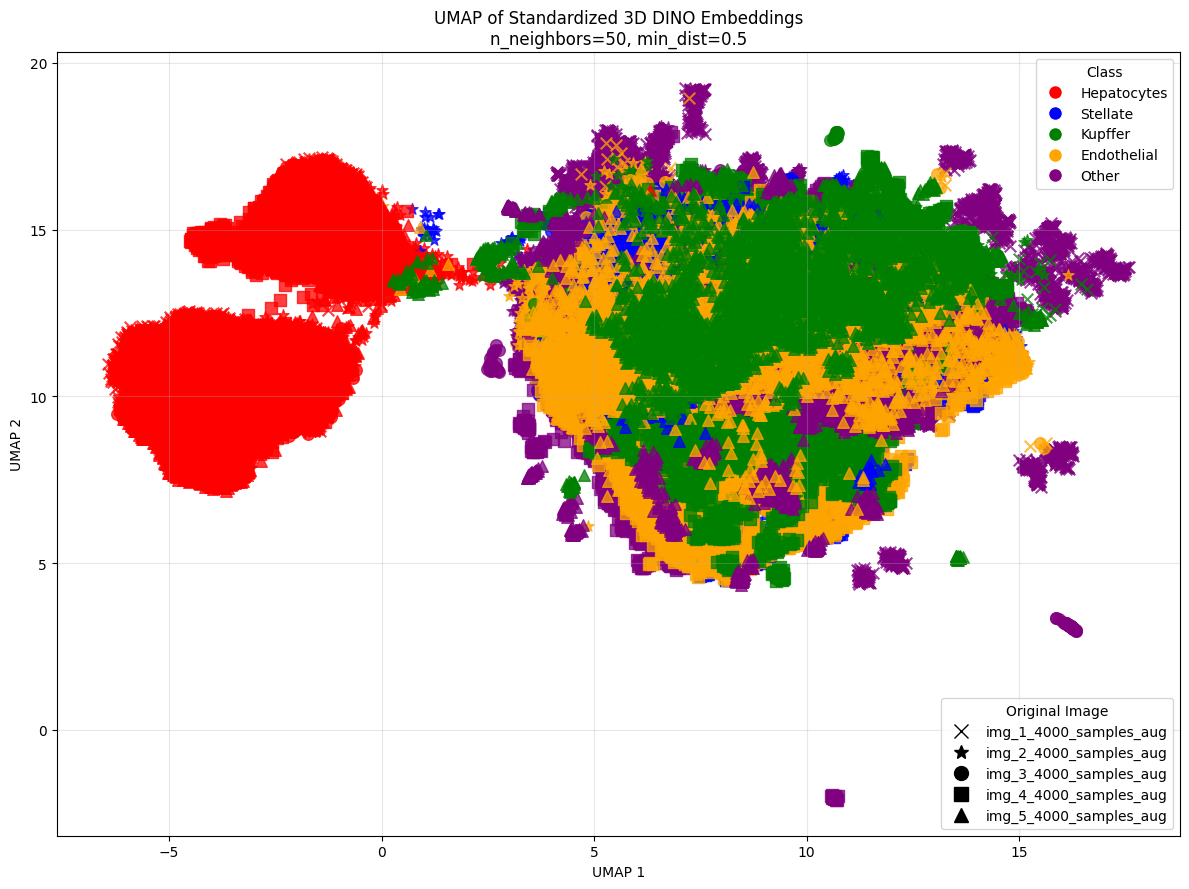


Saved SVG: /content/drive/MyDrive/Paper/UMAP/DINO3D_embeddings4000/UMAP_Features4000_scaled_nn50_md0_5.svg


In [ ]:


import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler

try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False
    print("UMAP not available. Install with: !pip install umap-learn")


# ============================================================
# 1. Settings
# ============================================================

RNG = 42
np.random.seed(RNG)

data_root = "/content/drive/MyDrive/Paper/processed_data 1/processed_data/DINO3D_embeddings/embedding_aug_4000"

output_dir = Path("/content/drive/MyDrive/Paper/UMAP/DINO3D_embeddings4000")
output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Class mapping
# ============================================================

class_map = {
    1: "Hepatocytes",
    2: "Stellate",
    3: "Kupffer",
    4: "Endothelial",
    5: "Other"
}


# ============================================================
# 3. Colors and markers
# ============================================================

color_map = {
    "Hepatocytes": "red",
    "Stellate": "blue",
    "Kupffer": "green",
    "Endothelial": "orange",
    "Other": "purple"
}

available_markers = ["x", "*", "o", "s", "^", "D", "P", "v", "<", ">", "h", "X"]


# ============================================================
# 4. Load NPZ files
# ============================================================

npz_files = sorted(glob.glob(os.path.join(data_root, "*.npz")))

print(f"Found {len(npz_files)} NPZ files:")
for f in npz_files:
    print(" -", os.path.basename(f))

if len(npz_files) == 0:
    raise FileNotFoundError(f"No NPZ files found in: {data_root}")


all_embeddings = []
all_labels = []
all_image_ids = []

for file_path in npz_files:
    data = np.load(file_path, allow_pickle=True)

    print(f"\nChecking file: {os.path.basename(file_path)}")
    print("Keys:", data.files)

    X_file = data["embeddings"]
    y_file = data["labels"]

    image_id = os.path.splitext(os.path.basename(file_path))[0]

    all_embeddings.append(X_file)
    all_labels.append(y_file)
    all_image_ids.extend([image_id] * len(y_file))


X = np.vstack(all_embeddings)
y = np.concatenate(all_labels)
image_ids = np.array(all_image_ids)

print("\nFinal merged shapes:")
print("Embeddings:", X.shape)
print("Labels:", y.shape)
print("Image IDs:", image_ids.shape)


# ============================================================
# 5. StandardScaler
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardized shape:", X_scaled.shape)


# ============================================================
# 6. Base DataFrame
# ============================================================

df_base = pd.DataFrame({
    "label": y,
    "image_id": image_ids
})

df_base["class_name"] = df_base["label"].map(class_map)

print("\nClass counts:")
print(df_base["class_name"].value_counts(dropna=False))


# ============================================================
# 7. Marker assignment
# ============================================================

unique_images = sorted(df_base["image_id"].unique())

if len(unique_images) > len(available_markers):
    raise ValueError(
        f"There are {len(unique_images)} NPZ files, but only "
        f"{len(available_markers)} markers are defined."
    )

marker_map = {img: available_markers[i] for i, img in enumerate(unique_images)}

print("\nMarker assignment:")
for img, marker in marker_map.items():
    print(f"{img}: {marker}")


# ============================================================
# 8. Run UMAP only with n_neighbors=50, min_dist=0.5
# ============================================================

if UMAP_AVAILABLE:

    n_neighbors = 50
    min_dist = 0.5

    print(f"\nRunning UMAP with n_neighbors={n_neighbors}, min_dist={min_dist}")

    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=RNG
    )

    X_umap = umap_model.fit_transform(X_scaled)

    df = df_base.copy()
    df["UMAP1"] = X_umap[:, 0]
    df["UMAP2"] = X_umap[:, 1]


    # ============================================================
    # 9. Plot UMAP
    # ============================================================

    plt.figure(figsize=(12, 9))

    for img in unique_images:
        for cls in df["class_name"].dropna().unique():
            subset = df[(df["image_id"] == img) & (df["class_name"] == cls)]

            if subset.empty:
                continue

            plt.scatter(
                subset["UMAP1"],
                subset["UMAP2"],
                c=color_map[cls],
                marker=marker_map[img],
                s=70,
                alpha=0.75
            )

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("UMAP of Standardized 3D DINO Embeddings\nn_neighbors=50, min_dist=0.5")

    class_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=cls,
            markerfacecolor=color,
            markersize=10
        )
        for cls, color in color_map.items()
    ]

    image_handles = [
        Line2D(
            [0], [0],
            marker=marker_map[img],
            color="black",
            linestyle="None",
            label=img,
            markersize=10
        )
        for img in unique_images
    ]

    legend1 = plt.legend(handles=class_handles, title="Class", loc="upper right")
    plt.gca().add_artist(legend1)

    plt.legend(handles=image_handles, title="Original Image", loc="lower right")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()


    # ============================================================
    # 10. Save SVG
    # ============================================================

    output_path = output_dir / "UMAP_Features4000_scaled_nn50_md0_5.svg"

    plt.savefig(output_path, format="svg", bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    print(f"\nSaved SVG: {output_path}")

else:
    print("UMAP not installed. Run: !pip install umap-learn")